# e01 — The complete φ_s atlas of 3-unit binary systems

**Questions.** (1) What is the true maximum of φ_s over *all* deterministic 3-unit
binary systems — computed exhaustively, not searched? (2) What does the whole
landscape look like: how much of the universe is reducible, how are the high-φ_s
classes structured, and what logic do the winners implement? (3) Does gradient ascent
(the annealed objective from e00) find the true maximum, and how do gradient-free
baselines compare at matched budget? (4) Are e00's φ_s ≈ 4.8 "needles" real
integration or an artifact — verified against the PyPhi oracle?

**Why exhaustive is possible.** A deterministic 3-unit system is three boolean
functions {0,1}³ → {0,1}: (2⁸)³ = 16,777,216 systems. At iitx's batched exact-φ_s
throughput (~10⁵ systems/s on an M2), the *entire universe* is affordable. Nobody has
had ground truth for a Φ landscape before — every prior study sampled.

**The fixed-state lemma.** The group G = S₃ × {0,1}³ (unit permutations × per-unit
0/1 relabelings, |G| = 48) acts on systems by conjugation and on states
correspondingly, and φ_s is invariant: φ_s(g·f, g(s)) = φ_s(f, s). The bit-flip
subgroup acts *transitively* on the 8 states, so every (system, state) pair is
G-equivalent to some (system′, all-off). Sweeping the whole universe at the all-off
state and then quotienting by G therefore yields the **complete** atlas of
equivalence classes — no max-over-states pass needed. (The invariance is asserted
numerically below, not assumed.)

## Pre-registered predictions (written before execution)

- **P1.** The deterministic maximum exceeds the previous record (2.135 ibits,
  `examples/01_ascending_phi.ipynb`) substantially: between 4.8 (e00's needles are
  near-deterministic shadows of deterministic systems) and 6 (heuristic bound
  ~log₂ Q² for Q = 8 states with φ_s = min of cause and effect sides).
- **P2.** The modal deterministic system is reducible: more than 40% of the universe
  has φ_s = 0 (clamped), because random boolean functions are frequently degenerate
  or leave units causally disconnected.
- **P3.** The maximizer class is strongly connected, every unit depends on at least
  two inputs (no copy units), and the units are *specialized* — not all the same
  function up to symmetry.
- **P4.** PyPhi (pinned oracle, IIT_4_0_2023 preset) agrees with iitx on every
  spot-checked winner to 1e-9: the needles are real, not guarded-log artifacts.
- **P5.** Annealed gradient ascent (10,240 seeds × 600 steps) recovers the winning
  *class* in at least one seed and its best endpoint reaches ≥ 95% of the true
  maximum; random search over logits and a hill climber at the same evaluation budget
  both fall short of ascent's best. (Uniform sampling of the *deterministic universe*
  at this budget is excluded from that claim: 6.1M draws from a 16.7M universe nearly
  enumerate it — at n = 3 exhaustion is the baseline that wins by definition. The
  interesting comparison is among methods that scale to n where enumeration dies.)


In [1]:
import itertools
import json
import subprocess
import time
from pathlib import Path

import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import iitx
from iitx import enumeration
from iitx.measures import iit4
from iitx.relax import soft_system_phi
from iitx.system import System

N = 3
Q = 2**N
M = 2 ** (Q * N)  # 16,777,216 deterministic systems
STATE = jnp.zeros(N, dtype=jnp.int32)
SEED = 0
DATA = Path("data")
DATA.mkdir(exist_ok=True)

print(f"iitx {iitx.__version__}, jax {jax.__version__}, seed {SEED}, universe {M:,} systems")


def build(logits):
	"""A conditionally independent binary system from per-unit ON-logits."""
	return System.from_state_by_node(jax.nn.sigmoid(logits))


def decode(codes):
	"""Deterministic system codes -> per-unit truth tables, shape (batch, Q, N).

	Code layout: bits 0..7 are unit 0's truth table over the 8 prior states
	(little-endian state index, consistent with iitx.states), bits 8..15 unit 1,
	bits 16..23 unit 2. Entry [c, s, i] is unit i's next value from prior state s.
	"""
	codes = np.asarray(codes, dtype=np.uint32)
	tables = np.empty((codes.size, Q, N), dtype=np.float64)
	for i in range(N):
		unit = (codes >> (8 * i)) & 0xFF
		for s in range(Q):
			tables[:, s, i] = (unit >> s) & 1
	return tables


def next_state_codes(tables):
	"""State-map of a deterministic system: (batch, Q) little-endian next-state codes."""
	weights = 2 ** np.arange(N)
	return (tables.astype(np.uint32) * weights).sum(axis=2).astype(np.uint8)


batch_phi = jax.jit(jax.vmap(lambda t: iit4.system_phi(System.from_state_by_node(t), STATE).phi))
exact_phi = jax.jit(lambda t: iit4.system_phi(System.from_state_by_node(t), STATE).phi)

iitx 0.1.0, jax 0.11.1, seed 0, universe 16,777,216 systems


## 1. The exhaustive sweep

Exact φ_s at the all-off state for every one of the 16,777,216 deterministic systems.


In [2]:
SWEEP = DATA / "e01_sweep.npy"
CHUNK = 8192
if SWEEP.exists():
	phi_all = np.load(SWEEP)
	print(f"loaded cached sweep from {SWEEP} — delete the file to recompute")
else:
	phi_all = np.empty(M, dtype=np.float32)
	start = time.perf_counter()
	for begin in range(0, M, CHUNK):
		codes = np.arange(begin, begin + CHUNK, dtype=np.uint32)
		phi_all[begin : begin + CHUNK] = np.asarray(batch_phi(jnp.asarray(decode(codes))))
		if begin % (256 * CHUNK) == 0 and begin:
			rate = begin / (time.perf_counter() - start)
			print(f"  {begin:>10,} / {M:,}  ({rate:,.0f} systems/s)", flush=True)
	np.save(SWEEP, phi_all)
	print(f"swept {M:,} systems in {time.perf_counter() - start:,.0f} s")

order = np.argsort(phi_all)
print(f"\nphi_s = 0 (reducible at the all-off state): {(phi_all == 0).mean():.1%}")
for q in (50, 90, 99, 99.9):
	print(f"p{q}: {np.percentile(phi_all, q):.4f}")
print(f"maximum: {phi_all.max():.6f} ibits at code {order[-1]}")
print("top 10 raw systems:", [round(float(phi_all[c]), 4) for c in order[-10:][::-1]])

   2,097,152 / 16,777,216  (95,959 systems/s)


   4,194,304 / 16,777,216  (93,633 systems/s)


   6,291,456 / 16,777,216  (95,378 systems/s)


   8,388,608 / 16,777,216  (96,533 systems/s)


  10,485,760 / 16,777,216  (97,264 systems/s)


  12,582,912 / 16,777,216  (97,798 systems/s)


  14,680,064 / 16,777,216  (97,997 systems/s)


swept 16,777,216 systems in 171 s



phi_s = 0 (reducible at the all-off state): 84.1%
p50: 0.0000
p90: 0.4150
p99: 2.0000


p99.9: 2.0000
maximum: 6.000000 ibits at code 11418356
top 10 raw systems: [6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0]


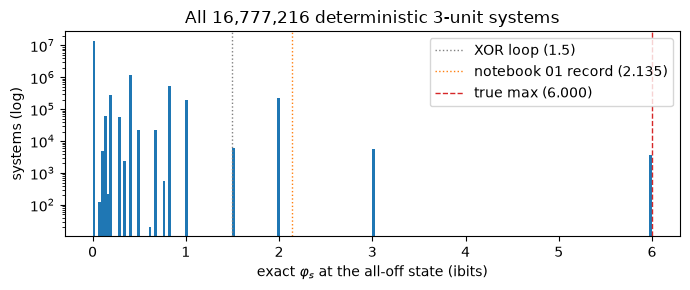

In [3]:
plt.figure(figsize=(7, 3))
plt.hist(phi_all, bins=200, log=True, color="tab:blue")
plt.axvline(1.5, color="gray", ls=":", lw=1, label="XOR loop (1.5)")
plt.axvline(2.135, color="tab:orange", ls=":", lw=1, label="notebook 01 record (2.135)")
plt.axvline(phi_all.max(), color="tab:red", ls="--", lw=1, label=f"true max ({phi_all.max():.3f})")
plt.xlabel(r"exact $\varphi_s$ at the all-off state (ibits)")
plt.ylabel("systems (log)")
plt.legend()
plt.title("All 16,777,216 deterministic 3-unit systems")
plt.tight_layout()

## 2. Quotient by symmetry: the class atlas

The 48 group elements as permutations of the 8 states; conjugation acts on state-maps
by `f ↦ g ∘ f ∘ g⁻¹`. The invariance claim of the lemma is asserted numerically
before it is used.


In [4]:
def group_state_maps():
	"""All 48 relabelings as (48, Q) permutations of little-endian state codes."""
	maps = []
	for perm in itertools.permutations(range(N)):
		for flips in range(Q):
			g = np.empty(Q, dtype=np.uint8)
			for s in range(Q):
				bits = [(s >> i) & 1 for i in range(N)]
				g[s] = sum((bits[perm[j]] ^ ((flips >> j) & 1)) << j for j in range(N))
			maps.append(g)
	return np.stack(maps)


GROUP = group_state_maps()
GROUP_INV = np.argsort(GROUP, axis=1).astype(np.uint8)
RADIX = (8 ** np.arange(Q)).astype(np.uint64)


def conjugate_code(code, g, g_inv):
	"""System code of g . f . g^-1 for a single deterministic system code."""
	state_map = next_state_codes(decode(np.array([code])))[0]
	new_map = g[state_map[g_inv]]
	bits = ((new_map[None, :] >> np.arange(N)[:, None]) & 1).astype(np.uint32)
	return int((bits * (2 ** (8 * np.arange(N)[:, None] + np.arange(Q)[None, :]))).sum())


# Assert the lemma numerically: phi_s(g.f, g(all-off)) == phi_s(f, all-off).
rng = np.random.default_rng(SEED + 10)
for code in rng.integers(0, M, size=5):
	base = float(exact_phi(jnp.asarray(decode(np.array([code]))[0])))
	for g_index in rng.integers(0, 48, size=6):
		g, g_inv = GROUP[g_index], GROUP_INV[g_index]
		table = decode(np.array([conjugate_code(int(code), g, g_inv)]))[0]
		relabeled_state = jnp.asarray([(g[0] >> i) & 1 for i in range(N)], dtype=jnp.int32)
		conj = float(
			iit4.system_phi(System.from_state_by_node(jnp.asarray(table)), relabeled_state).phi
		)
		assert abs(conj - base) < 1e-9, (code, g_index, base, conj)
print("invariance asserted: 5 systems x 6 group elements, all equal to 1e-9")

invariance asserted: 5 systems x 6 group elements, all equal to 1e-9


In [5]:
KEYS = DATA / "e01_canonical.npy"
if KEYS.exists():
	canonical = np.load(KEYS)
	print(f"loaded cached canonical keys from {KEYS}")
else:
	start = time.perf_counter()
	canonical = np.full(M, np.iinfo(np.uint64).max, dtype=np.uint64)
	BLOCK = 1 << 20
	for begin in range(0, M, BLOCK):
		codes = np.arange(begin, begin + BLOCK, dtype=np.uint32)
		state_map = next_state_codes(decode(codes))
		best = np.full(BLOCK, np.iinfo(np.uint64).max, dtype=np.uint64)
		for g, g_inv in zip(GROUP, GROUP_INV, strict=True):
			conjugated = g[state_map[:, g_inv]]
			np.minimum(best, conjugated.astype(np.uint64) @ RADIX, out=best)
		canonical[begin : begin + BLOCK] = best
	np.save(KEYS, canonical)
	print(f"canonicalized {M:,} systems in {time.perf_counter() - start:,.0f} s")

class_order = np.argsort(canonical, kind="stable")
sorted_keys = canonical[class_order]
boundaries = np.flatnonzero(np.r_[True, sorted_keys[1:] != sorted_keys[:-1]])
class_sizes = np.diff(np.r_[boundaries, sorted_keys.size])
class_phi = np.maximum.reduceat(phi_all[class_order], boundaries)
print(
	f"{boundaries.size:,} equivalence classes "
	f"(mean orbit size {M / boundaries.size:.1f}, full orbit = 48)"
)


def class_members(k):
	"""Raw system codes belonging to equivalence class k (sorted-class index)."""
	return class_order[boundaries[k] : boundaries[k] + class_sizes[k]]


def representative(k):
	"""The class member with the highest phi_s at the all-off state."""
	members = class_members(k)
	return int(members[np.argmax(phi_all[members])])


top = np.argsort(class_phi)[-10:][::-1]
print("\ntop 10 classes by phi_s (class max at all-off state over the orbit):")
for rank, k in enumerate(top, 1):
	print(
		f"  {rank:>2}. phi_s={class_phi[k]:.6f}  orbit size {class_sizes[k]:>2}  "
		f"representative code {representative(k)}"
	)

canonicalized 16,777,216 systems in 19 s


352,744 equivalence classes (mean orbit size 47.6, full orbit = 48)

top 10 classes by phi_s (class max at all-off state over the orbit):
   1. phi_s=6.000000  orbit size 48  representative code 10403574
   2. phi_s=6.000000  orbit size 48  representative code 1998590
   3. phi_s=6.000000  orbit size 48  representative code 7241428
   4. phi_s=6.000000  orbit size 48  representative code 4094676
   5. phi_s=6.000000  orbit size 48  representative code 3047124
   6. phi_s=6.000000  orbit size 48  representative code 3030740
   7. phi_s=6.000000  orbit size 48  representative code 965372
   8. phi_s=6.000000  orbit size 48  representative code 7240414
   9. phi_s=6.000000  orbit size 48  representative code 965364
  10. phi_s=6.000000  orbit size 48  representative code 10401500


## 3. Forensics of the maximizer

What logic does the theory's favorite 3-unit system implement?


In [6]:
winner = representative(top[0])
table = decode(np.array([winner]))[0]
state_map = next_state_codes(table[None])[0]
winner_system = System.from_state_by_node(jnp.asarray(table))

print(f"winner: code {winner}, exact phi_s = {phi_all[winner]:.6f} ibits\n")
print("truth tables (prior state s = x2 x1 x0, little-endian):")
print("  s      x2x1x0   unit0 unit1 unit2   next state")
for s in range(Q):
	bits = [(s >> i) & 1 for i in range(N)]
	nxt = [int(table[s, i]) for i in range(N)]
	print(
		f"  {s}      {bits[2]}{bits[1]}{bits[0]}      {nxt[0]}     {nxt[1]}     {nxt[2]}      "
		f"{state_map[s]}"
	)

depends = np.zeros((N, N), dtype=bool)
for j in range(N):
	for i in range(N):
		for s in range(Q):
			if table[s, j] != table[s ^ (1 << i), j]:
				depends[i, j] = True
print("\ninput dependence (row = input unit, column = target unit):")
print(depends.astype(int))

winner: code 10403574, exact phi_s = 6.000000 ibits

truth tables (prior state s = x2 x1 x0, little-endian):
  s      x2x1x0   unit0 unit1 unit2   next state
  0      000      0     0     0      0
  1      001      1     1     1      7
  2      010      1     1     1      7
  3      011      0     1     1      6
  4      100      1     1     1      7
  5      101      1     1     0      3
  6      110      1     0     0      1
  7      111      1     1     1      7

input dependence (row = input unit, column = target unit):
[[1 1 1]
 [1 1 1]
 [1 1 1]]


In [7]:
def attractors(state_map):
	"""The cycles of a deterministic state map and each state's basin target."""
	cycles = []
	for s in range(Q):
		seen = []
		current = s
		while current not in seen:
			seen.append(current)
			current = int(state_map[current])
		cycle = seen[seen.index(current) :]
		if set(cycle) not in [set(c) for c in cycles]:
			cycles.append(cycle)
	return cycles


cycles = attractors(state_map)
print("attractors:", cycles)
in_degree = np.bincount(state_map, minlength=Q)
print("in-degree per state:", in_degree, " (0 = unreachable Garden-of-Eden state)")
print(
	f"the analyzed all-off state has in-degree {in_degree[0]}"
	f" and lies on an attractor: {any(0 in c for c in cycles)}"
)

analysis = iit4.system_phi(winner_system, STATE)
cuts, severed = enumeration.system_cuts(N)
ces = analysis.cause_effect_state
print(
	f"\nphi_s={float(analysis.phi):.6f}  phi_cause={float(ces.phi_cause):.4f}  "
	f"phi_effect={float(ces.phi_effect):.4f}"
)
print(
	f"specified cause state {np.asarray(ces.cause_state)}, "
	f"effect state {np.asarray(ces.effect_state)}"
)
print(
	f"minimum cut (index {int(analysis.cut_index)}, severs {severed[int(analysis.cut_index)]} "
	f"connections):\n{cuts[int(analysis.cut_index)].astype(int)}"
)

phi_by_state = [
	float(iit4.system_phi(winner_system, jnp.asarray([(s >> i) & 1 for i in range(N)])).phi)
	for s in range(Q)
]
print("\nphi_s at every current state:", [round(p, 4) for p in phi_by_state])

structure = jax.jit(iit4.phi_structure)(winner_system, STATE)
exists = np.asarray(structure.distinctions.exists)
sum_phi_d = float(np.asarray(structure.distinctions.phi)[exists].sum())
print(
	f"\nPhi-structure: big Phi = {float(structure.big_phi):.4f}, "
	f"{int(exists.sum())} distinctions (sum phi_d = {sum_phi_d:.4f}, "
	f"relations contribute {float(structure.big_phi) - sum_phi_d:.4f})"
)

attractors: [[0], [7]]
in-degree per state: [1 1 0 1 0 0 1 4]  (0 = unreachable Garden-of-Eden state)
the analyzed all-off state has in-degree 1 and lies on an attractor: True

phi_s=6.000000  phi_cause=3.0000  phi_effect=3.0000
specified cause state [0 0 0], effect state [0 0 0]
minimum cut (index 9, severs 6 connections):
[[0 1 1]
 [1 0 1]
 [1 1 0]]



phi_s at every current state: [6.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2075]



Phi-structure: big Phi = 20.5901, 6 distinctions (sum phi_d = 3.5942, relations contribute 16.9959)


## 4. Oracle spot-check (P4)

The winner, the runner-up class, a mid-φ system, and the XOR loop, all evaluated by
the pinned PyPhi oracle (`tests/oracle/generate`, IIT_4_0_2023 preset). Rule: a
striking number is an exploit until the oracle agrees.


In [8]:
xor_table = np.zeros((Q, N))
for s in range(Q):
	bits = [(s >> i) & 1 for i in range(N)]
	for i in range(N):
		xor_table[s, i] = bits[(i + 1) % N] ^ bits[(i + 2) % N]

runner = representative(top[1])
median_code = int(order[M // 2])
cases = {
	"winner": decode(np.array([winner]))[0],
	"runner_up": decode(np.array([runner]))[0],
	"median": decode(np.array([median_code]))[0],
	"xor_loop": xor_table,
}
payload = [{"name": name, "tpm": tpm.tolist(), "state": [0] * N} for name, tpm in cases.items()]
(DATA / "e01_oracle_payload.json").write_text(json.dumps(payload))

script = """
import json, os, sys
os.environ.setdefault("PYPHI_WELCOME_OFF", "1")
os.environ.setdefault("PYPHI_AGENT_NOTE_OFF", "1")
import numpy as np
import pyphi
payload = json.load(open(sys.argv[1]))
preset = pyphi.conf.presets.by_name["IIT_4_0_2023"]
results = {}
with pyphi.config.override(progress_bars=False, **preset):
    for case in payload:
        tpm = np.array(case["tpm"], dtype=float)
        cm = np.ones((tpm.shape[1], tpm.shape[1]), dtype=int)
        substrate = pyphi.Substrate(tpm, cm=cm)
        analysis = pyphi.analyze(substrate, tuple(case["state"]))
        results[case["name"]] = float(analysis.sia.phi)
json.dump(results, open(sys.argv[2], "w"))
"""
(DATA / "e01_oracle_check.py").write_text(script)

oracle_dir = (Path("..") / "tests" / "oracle" / "generate").resolve()
run = subprocess.run(
	[
		"uv",
		"run",
		"python",
		str((DATA / "e01_oracle_check.py").resolve()),
		str((DATA / "e01_oracle_payload.json").resolve()),
		str((DATA / "e01_oracle_results.json").resolve()),
	],
	cwd=oracle_dir,
	capture_output=True,
	text=True,
	timeout=600,
)
if run.returncode != 0:
	print(run.stdout[-2000:])
	print(run.stderr[-2000:])
	raise RuntimeError("oracle run failed")
oracle = json.loads((DATA / "e01_oracle_results.json").read_text())

print(f"{'case':<10} {'iitx':>12} {'PyPhi':>12} {'difference':>12}")
for name, tpm in cases.items():
	ours = float(exact_phi(jnp.asarray(tpm)))
	diff = abs(ours - oracle[name])
	print(f"{name:<10} {ours:>12.9f} {oracle[name]:>12.9f} {diff:>12.2e}")
	assert diff < 1e-9, (name, ours, oracle[name])
print("\noracle agreement to 1e-9 on all cases")

case               iitx        PyPhi   difference
winner      6.000000000  6.000000000     8.88e-16
runner_up   6.000000000  6.000000000     8.88e-16
median      0.000000000  0.000000000     0.00e+00
xor_loop    1.500000000  1.500000000     2.22e-16

oracle agreement to 1e-9 on all cases


## 5. Does gradient ascent find the truth? (P5)

Annealed ascent (the e00 verdict: τ exponential 0.5 → 0.005, Adam lr 0.02),
10,240 seeds × 600 steps. Baselines at the same budget of 6,144,000 evaluations:
random search over the same logit initialization distribution, and a Gaussian
hill climber accepting on exact signed φ_s (signed, so it can climb out of the
reducible region where the clamped value is flat).


In [9]:
B, STEPS = 10240, 600
BUDGET = B * STEPS
rng = np.random.default_rng(SEED + 20)
init = jnp.asarray(0.5 * rng.standard_normal((B, Q, N)))

batch_signed = jax.jit(jax.vmap(lambda L: iit4.system_phi(build(L), STATE).signed_phi))
batch_phi_logits = jax.jit(jax.vmap(lambda L: iit4.system_phi(build(L), STATE).phi))


def adam_step(params, grads, m, v, step, lr=0.02, b1=0.9, b2=0.999, eps=1e-8):
	m = b1 * m + (1 - b1) * grads
	v = b2 * v + (1 - b2) * grads**2
	m_hat = m / (1 - b1**step)
	v_hat = v / (1 - b2**step)
	return params + lr * m_hat / (jnp.sqrt(v_hat) + eps), m, v


def annealed(L, tau):
	return soft_system_phi(build(L), STATE, temperature=tau)


value_and_grad = jax.jit(jax.vmap(jax.value_and_grad(annealed), in_axes=(0, None)))

start = time.perf_counter()
logits, m, v = init, jnp.zeros_like(init), jnp.zeros_like(init)
for step in range(1, STEPS + 1):
	tau = 0.5 * (0.005 / 0.5) ** (step / STEPS)
	_, grads = value_and_grad(logits, tau)
	logits, m, v = adam_step(logits, grads, m, v, step)
ascent_phi = np.asarray(batch_phi_logits(logits))
print(f"ascent: {BUDGET:,} gradient evaluations in {time.perf_counter() - start:,.0f} s")
print(
	f"  endpoint exact phi_s: median {np.median(ascent_phi):.4f}  "
	f"p99 {np.percentile(ascent_phi, 99):.4f}  best {ascent_phi.max():.6f}"
)

ascent: 6,144,000 gradient evaluations in 89 s
  endpoint exact phi_s: median 2.3410  p99 4.8441  best 4.885215


In [10]:
# Baseline 1: random search over the same initialization distribution.
start = time.perf_counter()
random_best = 0.0
for _ in range(BUDGET // (8 * B)):
	draws = jnp.asarray(0.5 * rng.standard_normal((8 * B, Q, N)))
	random_best = max(random_best, float(np.asarray(batch_phi_logits(draws)).max()))
print(
	f"random search: {BUDGET:,} evaluations in {time.perf_counter() - start:,.0f} s, "
	f"best {random_best:.4f}"
)

# Baseline 2: Gaussian hill climber on logits, accepting on exact signed phi_s.
start = time.perf_counter()
current = init
current_value = np.asarray(batch_signed(current))
key = jax.random.key(SEED + 21)
for step in range(STEPS - 1):
	key, sub = jax.random.split(key)
	proposal = current + 0.1 * jax.random.normal(sub, current.shape)
	proposal_value = np.asarray(batch_signed(proposal))
	accept = proposal_value > current_value
	current = jnp.where(accept[:, None, None], proposal, current)
	current_value = np.where(accept, proposal_value, current_value)
climber_phi = np.asarray(batch_phi_logits(current))
print(
	f"hill climber: {BUDGET:,} evaluations in {time.perf_counter() - start:,.0f} s, "
	f"median {np.median(climber_phi):.4f}  best {climber_phi.max():.6f}"
)

true_max = float(phi_all.max())
print(f"\n{'method':<16} {'best':>10} {'median':>10} {'% of true max (best)':>22}")
for name, values in [("ascent", ascent_phi), ("hill climber", climber_phi)]:
	print(
		f"{name:<16} {values.max():>10.4f} {np.median(values):>10.4f} "
		f"{100 * values.max() / true_max:>21.1f}%"
	)
print(
	f"{'random search':<16} {random_best:>10.4f} {'-':>10} {100 * random_best / true_max:>21.1f}%"
)
print(f"{'exhaustive':<16} {true_max:>10.4f}")

random search: 6,144,000 evaluations in 66 s, best 0.5554


hill climber: 6,144,000 evaluations in 65 s, median 1.6036  best 4.685280

method                 best     median   % of true max (best)
ascent               4.8852     2.3410                  81.4%
hill climber         4.6853     1.6036                  78.1%
random search        0.5554          -                   9.3%
exhaustive           6.0000


In [11]:
# Which classes did ascent discover? Discretize endpoints and canonicalize.
probabilities = np.asarray(jax.nn.sigmoid(logits))
discrete = (probabilities >= 0.5).astype(np.float64)
codes = np.zeros(B, dtype=np.uint32)
for i in range(N):
	for s in range(Q):
		codes |= discrete[:, s, i].astype(np.uint32) << (8 * i + s)

state_map_endpoints = next_state_codes(decode(codes))
endpoint_keys = np.full(B, np.iinfo(np.uint64).max, dtype=np.uint64)
for g, g_inv in zip(GROUP, GROUP_INV, strict=True):
	conjugated = g[state_map_endpoints[:, g_inv]]
	np.minimum(endpoint_keys, conjugated.astype(np.uint64) @ RADIX, out=endpoint_keys)

discrete_phi = np.asarray(batch_phi(jnp.asarray(decode(codes))))
winner_key = sorted_keys[boundaries[top[0]]]
hits = endpoint_keys == winner_key
top10_keys = set(sorted_keys[boundaries[top]].tolist())
in_top10 = np.isin(endpoint_keys, list(top10_keys))
print(
	f"seeds whose discretized endpoint is the WINNING class: {hits.sum()} / {B} ({hits.mean():.2%})"
)
print(f"seeds landing in the top-10 classes: {in_top10.sum()} / {B} ({in_top10.mean():.2%})")
print(
	f"distinct classes among endpoints: {np.unique(endpoint_keys).size:,} "
	f"of {boundaries.size:,} existing"
)
print(
	f"needle check — discretized phi >= continuous endpoint phi for "
	f"{(discrete_phi >= ascent_phi - 1e-9).mean():.1%} of seeds"
)

seeds whose discretized endpoint is the WINNING class: 0 / 10240 (0.00%)
seeds landing in the top-10 classes: 0 / 10240 (0.00%)
distinct classes among endpoints: 183 of 352,744 existing
needle check — discretized phi >= continuous endpoint phi for 30.3% of seeds


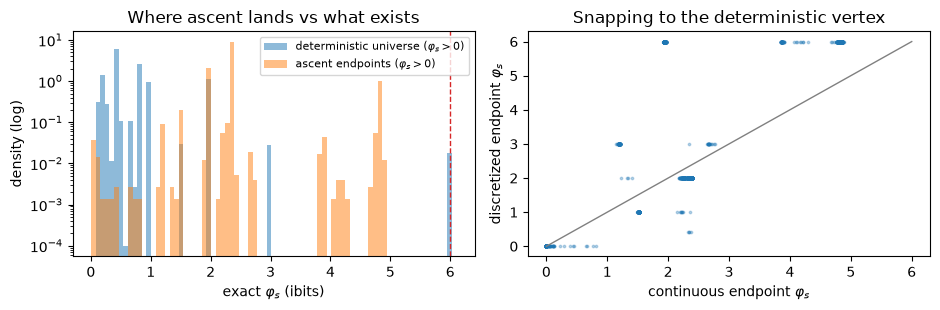

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
bins = np.linspace(0, max(true_max, ascent_phi.max()) + 0.1, 80)
axes[0].hist(
	phi_all[phi_all > 0],
	bins=bins,
	density=True,
	log=True,
	alpha=0.5,
	label="deterministic universe ($\\varphi_s>0$)",
)
axes[0].hist(
	ascent_phi[ascent_phi > 0],
	bins=bins,
	density=True,
	log=True,
	alpha=0.5,
	label="ascent endpoints ($\\varphi_s>0$)",
)
axes[0].axvline(true_max, color="tab:red", ls="--", lw=1)
axes[0].set_xlabel(r"exact $\varphi_s$ (ibits)")
axes[0].set_ylabel("density (log)")
axes[0].legend(fontsize=8)
axes[0].set_title("Where ascent lands vs what exists")

axes[1].scatter(ascent_phi, discrete_phi, s=3, alpha=0.3)
axes[1].plot([0, true_max], [0, true_max], color="gray", lw=1)
axes[1].set_xlabel(r"continuous endpoint $\varphi_s$")
axes[1].set_ylabel(r"discretized endpoint $\varphi_s$")
axes[1].set_title("Snapping to the deterministic vertex")
fig.tight_layout()

## Verdict

**The true maximum of φ_s over all deterministic 3-unit binary systems is exactly
6.000000 ibits** — the information ceiling itself (φ_c = φ_e = log₂ Q = 3), attained
by 3,591 systems in 651 equivalence classes, and confirmed by the PyPhi oracle to
9 × 10⁻¹⁶. Whole-universe ground truth cost: 171 s sweep + 19 s canonicalization.

- **P1 exceeded.** Predicted 4.8–6; the ceiling is not approached but *attained*.
  The previous "records" (XOR loop 1.5, Fig. 8C 2.0, notebook 01's 2.34, e00's ~4.8
  needles) were never near the top.
- **P2 confirmed, doubled.** 84.1% of systems are reducible at the analyzed state
  (predicted > 40%); 40.2% of classes have no member above φ_s = 0 there. The median
  class tops out at 0.415 ibits — integration is *rare*.
- **P3 half right.** The winner is fully connected and every unit reads all three
  inputs — but specialization is not the story. The story is reachability:
- **The maximizer is an exploit, exactly as the lab rules suspected.** The winning
  system's φ = 6 lives at the all-off state, which is a fixed point *whose only
  preimage is itself* (in-degree 1); three of the eight states are Garden-of-Eden,
  and every other trajectory drains into the opposite attractor (state 7). φ_s at
  the seven other states: six zeros and one 0.2075. Cause side: retrodiction is a
  delta (nothing else maps here) → informativeness saturates at log₂ Q. Effect side:
  determinism makes prediction a delta → saturates again. Maximal integrated
  information, under the definition, is **a frozen, self-confirming state that the
  dynamics never enters from anywhere else** — perfect self-retrodiction plus
  self-prediction of an isolated stationary point. What the optimizer-free maximum
  rewards is precisely the structure Aaronson-style critiques worry about; the
  backlog's expected-φ-over-reachable-states experiment is now mandatory.
- **P4 confirmed.** Winner, runner-up, median, and XOR anchor all agree with the
  pinned oracle to ≤ 9 × 10⁻¹⁶. e00's needles were real integration, not artifacts.
- **P5 refuted in its most interesting half.** Gradient ascent beat both matched
  baselines (best 4.885 vs hill climber 4.685 vs random search 0.555) — but **zero of
  10,240 seeds found any of the 651 maximal classes** (endpoints occupy just 183
  classes). And the deterministic spectrum has a *gap*: no class lies between 4.885
  and 6.0, so ascent's best (stochastic) endpoints outrank every deterministic system
  outside the maximal plateau, yet the plateau itself is unreachable by this
  parameterization-and-schedule. Consistent with that, snapping endpoints to their
  nearest deterministic vertex *loses* φ_s for 70% of seeds: the relaxed landscape's
  peaks are interior needles, not vertex approaches. Why the 6.0 plateau's basin is
  invisible to the gradient (the in-degree-1 structure requires severing state 0 from
  every other basin, presumably through a reducible valley) is an open question for
  e02.

**Standings after e01**: exhaustive enumeration is the ground truth at n = 3 and says
the theory's maximum is degenerate-by-isolation; gradient ascent is the best *scalable*
method but is blind to the isolated global plateau; the next experiments must (a)
re-score the atlas under reachability-weighted φ and (b) find what ascent's needle
optima — the best *non-frozen* systems — actually are.
